# 06 — Baseline Model
Logistic Regression baseline with stratified split. Report Precision, Recall, F1, ROC-AUC.

In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score,
                              precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROC = r'../data/processed'
df = pd.read_csv(f'{PROC}/feature_matrix.csv')
print(f"Feature matrix: {df.shape}")


Feature matrix: (500, 45)


In [2]:

# ── Prepare X, y ──
target = 'AttritionRisk_Label'
drop_cols = [target, 'EmployeeID'] if 'EmployeeID' in df.columns else [target]
X = df.drop(columns=drop_cols)
y = df[target]

# Ensure all boolean cols are int
X = X.astype(float)

print(f"X: {X.shape}, y distribution: {y.value_counts().to_dict()}")
class_ratio = y.value_counts(normalize=True)
print(f"Class balance:\n{class_ratio.round(3)}")
minority_pct = class_ratio.min()
print(f"\nMinority class: {minority_pct:.1%}")
if minority_pct < 0.20:
    print("⚠ Imbalanced dataset — using class_weight='balanced' and prioritizing Recall over Accuracy")


X: (500, 43), y distribution: {0: 445, 1: 55}
Class balance:
AttritionRisk_Label
0    0.89
1    0.11
Name: proportion, dtype: float64

Minority class: 11.0%
⚠ Imbalanced dataset — using class_weight='balanced' and prioritizing Recall over Accuracy


In [3]:

# ── Stratified train/test split ──
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")


Train: (400, 43), Test: (100, 43)
Train class balance: {0: 356, 1: 44}
Test class balance:  {0: 89, 1: 11}


In [4]:

# ── Logistic Regression baseline ──
# class_weight='balanced' compensates for class imbalance
# Scaler is critical for LR — features on different scales distort coefficients
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression Baseline ===")
print(classification_report(y_test, y_pred, target_names=['No Attrition','Attrition']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

baseline_metrics = {
    'model': 'Logistic Regression (Baseline)',
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_prob)
}
print(f"\nSummary: Precision={baseline_metrics['precision']:.3f}, Recall={baseline_metrics['recall']:.3f}, "
      f"F1={baseline_metrics['f1']:.3f}, ROC-AUC={baseline_metrics['roc_auc']:.3f}")


=== Logistic Regression Baseline ===
              precision    recall  f1-score   support

No Attrition       0.96      0.97      0.96        89
   Attrition       0.70      0.64      0.67        11

    accuracy                           0.93       100
   macro avg       0.83      0.80      0.81       100
weighted avg       0.93      0.93      0.93       100

ROC-AUC: 0.9469

Summary: Precision=0.700, Recall=0.636, F1=0.667, ROC-AUC=0.947


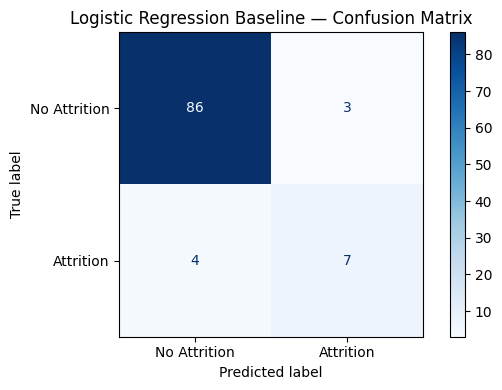

Confusion matrix saved.


In [5]:

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(cm, display_labels=['No Attrition','Attrition']).plot(ax=ax, cmap='Blues')
ax.set_title('Logistic Regression Baseline — Confusion Matrix')
plt.tight_layout()
plt.savefig('../models/baseline_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print("Confusion matrix saved.")


In [6]:

# ── Cross-validation for robustness ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(lr_pipeline, X, y, cv=cv, 
                             scoring=['precision','recall','f1','roc_auc'])
print("=== 5-Fold Cross-Validation ===")
for metric in ['precision','recall','f1','roc_auc']:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric}: {scores.mean():.3f} ± {scores.std():.3f}")


=== 5-Fold Cross-Validation ===
  precision: 0.725 ± 0.049
  recall: 0.927 ± 0.068
  f1: 0.810 ± 0.022
  roc_auc: 0.985 ± 0.006


In [7]:
import os

# ── Save baseline metrics for comparison in NB07 ──
import json
os.makedirs('../models', exist_ok=True)
with open('../models/baseline_metrics.json', 'w') as f:
    json.dump(baseline_metrics, f, indent=2)
print("Saved baseline_metrics.json")

import os


Saved baseline_metrics.json


**Baseline established.** Logistic Regression with `class_weight='balanced'` and stratified split. Metrics prioritize Recall (missing a flight-risk employee is the expensive mistake).